In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [2]:
DATA_DIR = Path("/Users/veronicahuang/Desktop/streaming-bi-template/Data")  # adjust if needed

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

movies = pd.read_csv(MOVIES_PATH)
tv = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:", tv.shape)

movies.head(3)

Movies shape: (9515, 19)
TV shape: (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,THE IRISHMAN
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,DANGAL
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,DAVID ATTENBOROUGH: A LIFE ON OUR PLANET


In [3]:
movies.columns

Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre',
       'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key'],
      dtype='str')

In [4]:
movies2 = movies.copy()
tv2 = tv.copy()

df = pd.concat([movies2, tv2], ignore_index=True)

# Basic sanity checks
df[["Title", "Year", "Type", "Netflix", "Hulu", "Prime Video", "Disney+", "Type"]].head()

,Title,Year,Type,Netflix,Hulu,Prime Video,Disney+,Type
0,The Irishman,2019,movie,1,0,0,0,movie
1,Dangal,2016,movie,1,0,0,0,movie
2,David Attenborough: A Life on Our Planet,2020,movie,1,0,0,0,movie
3,Lagaan: Once Upon a Time in India,2001,movie,1,0,0,0,movie
4,Roma,2018,movie,1,0,0,0,movie


In [5]:
platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]

def to_long_platform(df_in: pd.DataFrame) -> pd.DataFrame:
    base_cols = [c for c in df_in.columns if c not in platform_cols]

    # Melt platform indicator columns into rows
    melted = df_in.melt(
        id_vars=base_cols,
        value_vars=platform_cols,
        var_name="platform",
        value_name="on_platform"
    )

    # Keep only records where on_platform == 1
    long_df = melted[melted["on_platform"] == 1].drop(columns=["on_platform"])
    return long_df

df_long = to_long_platform(df)

print("Original rows:", len(df))
print("Long rows (one per platform):", len(df_long))
df_long[["Title", "Year", "Type", "platform", "Genre", "IMDb", "RottenTomatoes_Score"]].head()

Original rows: 14883
Long rows (one per platform): 15551


,Title,Year,Type,platform,Genre,IMDb,RottenTomatoes_Score
0,The Irishman,2019,movie,Netflix,"Biography, Crime, Drama",7.8,98.0
1,Dangal,2016,movie,Netflix,"Action, Biography, Drama",8.3,97.0
2,David Attenborough: A Life on Our Planet,2020,movie,Netflix,"Documentary, Biography",8.9,95.0
3,Lagaan: Once Upon a Time in India,2001,movie,Netflix,"Drama, Musical, Sport",8.1,94.0
4,Roma,2018,movie,Netflix,Drama,7.6,94.0


In [6]:
PLATFORM = "Hulu"
platform_df = df_long[df_long["platform"] == PLATFORM].copy()

print("Platform:", PLATFORM)
print("Rows:", platform_df.shape)
platform_df.head(3)

Platform: Hulu
Rows: (2668, 16)


,ID,Title,Year,Age,Rotten Tomatoes,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key,platform
14963,81,The Social Network,2010,13+,84/100,movie,"Biography, Drama",United States,"English, French",7.8,tt1285016,84.0,13.0,0,THE SOCIAL NETWORK,Hulu
14990,108,Hey Arnold! The Jungle Movie,2017,7+,83/100,movie,drama film,United States,English,7.0,tt0245844,83.0,7.0,0,HEY ARNOLD! THE JUNGLE MOVIE,Hulu
15050,168,Hunt for the Wilderpeople,2016,13+,80/100,movie,"Adventure, Comedy, Drama",New Zealand,English,7.8,tt4698684,80.0,13.0,0,HUNT FOR THE WILDERPEOPLE,Hulu


In [7]:
type_counts = platform_df["Type"].value_counts()

type_counts

Type
tv_show    1621
movie      1047
Name: count, dtype: int64

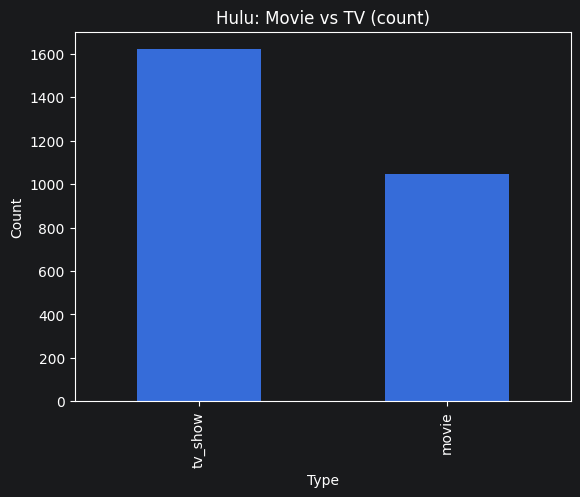

In [8]:
type_counts.plot(kind="bar")
plt.title(f"{PLATFORM}: Movie vs TV (count)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


Based on the **genre mix** and **release year distribution**, *Hulu* appears to focus on TV-first, broad-entertainment content with a strong concentration in recent programming.  
The platform's catalog is characterized by more TV shows than movies, with 1,621 TV shows compared with 1,047 movies, and dominant genres including reality television, drama film, drama television series, comedy film, and action film.  
The release year chart suggests Hulu is modern-content heavy, since releases cluster strongly after 2010 and especially from 2015-2019.  
Score distributions suggest a generally mid-to-solid catalog, but this should be interpreted carefully because IMDb data is missing for some titles.  
Overall, Hulu's content identity can be described as TV-oriented, contemporary, and broad-appeal, with reality, drama, and comedy shaping much of its catalog.  

**Claim:** Hulu is TV-oriented and modern-content heavy, with a broad entertainment mix.  
**Evidence:** TV shows outnumber movies, the top genres are reality television and drama-related categories, and release years cluster most heavily after 2010, especially 2015-2019.

In [9]:
def top_genres(df_in: pd.DataFrame, top_n: int = 10) -> pd.Series:
    g = df_in["Genre"].dropna().astype(str)
    # split on comma; if no comma, this still returns a single-item list
    exploded = g.str.split(",").explode().str.strip()
    exploded = exploded[exploded != ""]
    return exploded.value_counts().head(top_n)

genre_top = top_genres(platform_df, top_n=10)
genre_top

Genre
reality television                984
drama film                        552
drama television series           150
comedy film                       136
action film                       108
documentary film                  107
thriller film                      96
comedy drama                       90
horror film                        90
LGBT-related television series     77
Name: count, dtype: int64

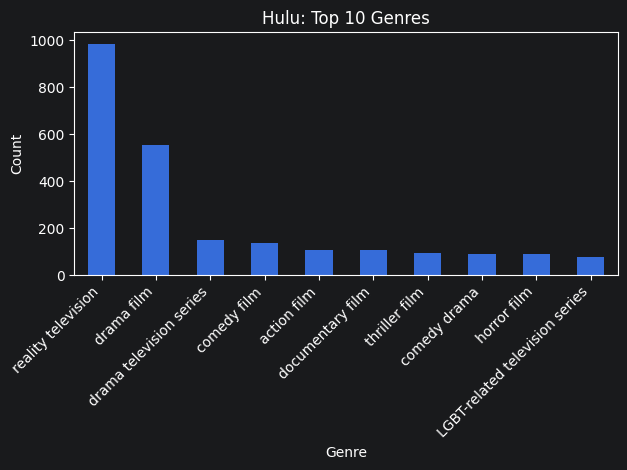

In [10]:
genre_top.plot(kind="bar")
plt.title(f"{PLATFORM}: Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


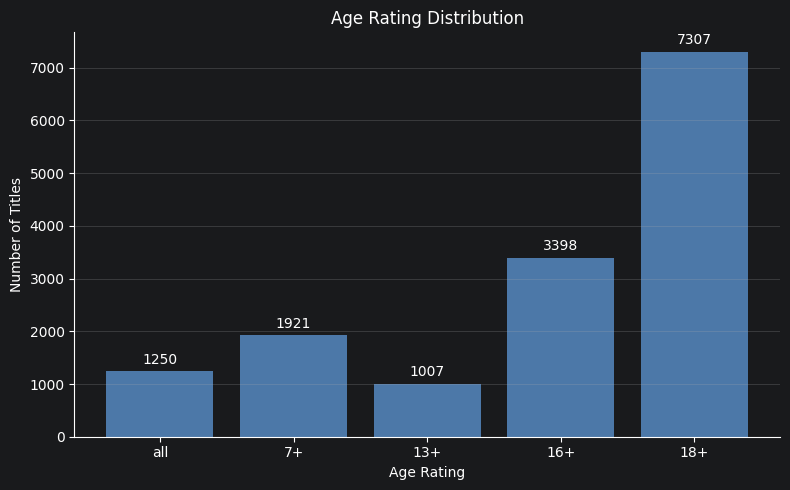

In [19]:

if 'movies' not in globals():
    movies = pd.read_csv(MOVIES_PATH)
if 'tv' not in globals():
    tv = pd.read_csv(TV_PATH)
if 'df' not in globals():
    df = pd.concat([movies, tv], ignore_index=True)

age_order = ['all', '7+', '13+', '16+', '18+']
age_counts = df['Age'].dropna().astype(str).str.strip().value_counts()
ordered_ages = [age for age in age_order if age in age_counts.index]
ordered_ages += [age for age in age_counts.index if age not in ordered_ages]
age_counts = age_counts.loc[ordered_ages]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(age_counts.index, age_counts.values, color='#4C78A8')

ax.bar_label(bars, padding=3)
ax.set_title('Age Rating Distribution')
ax.set_xlabel('Age Rating')
ax.set_ylabel('Number of Titles')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
platform_df["Year"] = pd.to_numeric(platform_df["Year"], errors="coerce")

platform_df["Year"].describe()

count    2668.000000
mean     2011.005997
std        11.080608
min      1923.000000
25%      2009.000000
50%      2014.000000
75%      2018.000000
max      2021.000000
Name: Year, dtype: float64

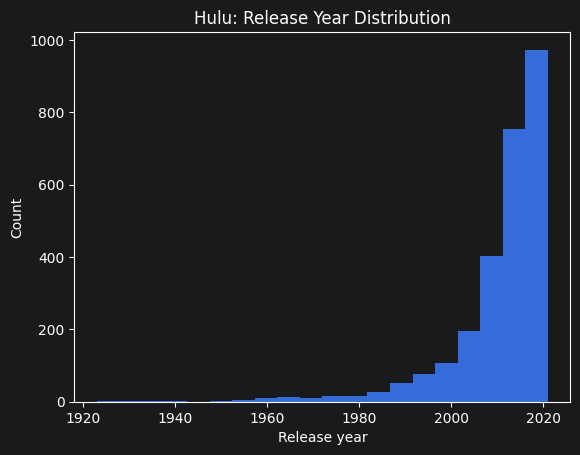

In [12]:
platform_df["Year"].dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Release Year Distribution")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.show()

IMDb non-null: 2092


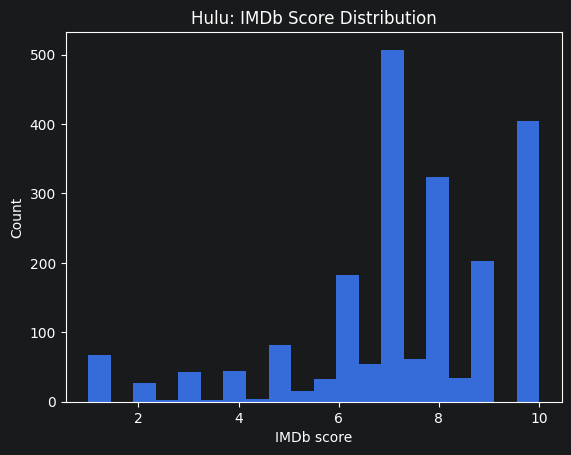

RottenTomatoes_Score non-null: 2668


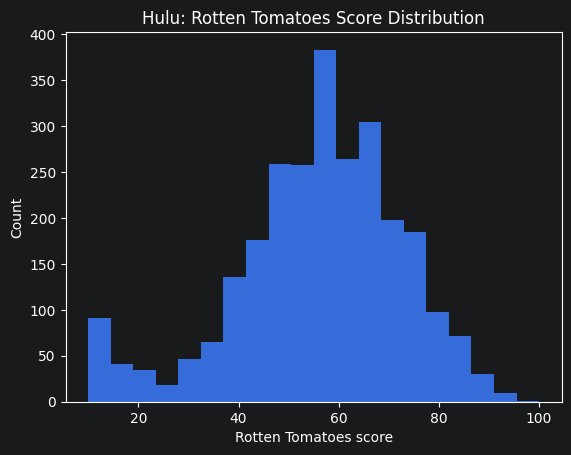

In [13]:
imdb = pd.to_numeric(platform_df["IMDb"], errors="coerce")
print("IMDb non-null:", imdb.notna().sum())

imdb.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: IMDb Score Distribution")
plt.xlabel("IMDb score")
plt.ylabel("Count")
plt.show()

# Rotten Tomatoes distribution
rt = pd.to_numeric(platform_df["RottenTomatoes_Score"], errors="coerce")
print("RottenTomatoes_Score non-null:", rt.notna().sum())

rt.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Rotten Tomatoes Score Distribution")
plt.xlabel("Rotten Tomatoes score")
plt.ylabel("Count")
plt.show()